<a href="https://colab.research.google.com/github/anushi12/Machine-Learning/blob/main/Supervised%20Learning/06_Lasso_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lasso Regression

Lasso = Linear regression + Penalty                   

But lasso can make coefficients exactly Zero which means -
  * Removes useless features
  * Performs feature selection automatically

Cost function:

    J(β)=(1/2n)​∑(y−y^​)2+λ∑∣β∣

It is also called L1 Regularization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## loss function

def lasso_reg(X,y, beta, lam):
  n = len(y)
  predictions = X.dot(beta)
  error = y - predictions
  mse = (1/(2*n))*np.sum(error**2)
  penalty = lam * np.sum(np.abs(beta))

  return mse + penalty

Coefficients: [0.         0.95454545]


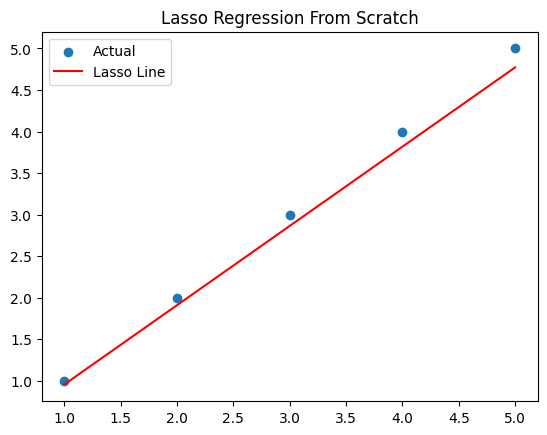

In [9]:
## gradient descent

def lasso_fit(X, y, lam = 1, learning_rate = 0.01, iterations = 1000):
  n, m = X.shape
  beta = np.zeros(m)

  for i in range(iterations):

      # predictions
      predictions = X @ beta

      # gradient of MSE
      gradient = -(1/n) * X.T @ (y - predictions)

      # gradient descent step
      beta = beta - learning_rate * gradient

      # soft thresholding (L1 penalty)
      beta = np.sign(beta) * np.maximum(0, np.abs(beta) - learning_rate * lam)

  return beta

# Prediction Function

def predict(X, beta):
  return X @ beta

# Example Data
X = np.array([
  [1],
  [2],
  [3],
  [4],
  [5]
])

y = np.array([1, 2, 3, 4, 5])

# add intercept
X = np.hstack([np.ones((X.shape[0],1)), X])

# Train Model

beta = lasso_fit(X, y, lam=0.5)

print("Coefficients:", beta)

# Predictions

y_pred = predict(X, beta)

# Visualization
plt.scatter(X[:,1], y, label="Actual")
plt.plot(X[:,1], y_pred, color="red", label="Lasso Line")

plt.legend()
plt.title("Lasso Regression From Scratch")
plt.show()